In [1]:
import firedrake
from firedrake import exp, sin, cos, max_value, Constant, interpolate, dx, sqrt, inner, as_vector
from firedrake_adjoint import ReducedFunctional, Control, minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import icepack
import icepack.plot
from icepack.constants import (
    ice_density as ρ_I,
    water_density as ρ_W,
    gravity as g,
    weertman_sliding_law as m
)
import os
import numpy as np
import tqdm
import random
from math import floor
from collections import deque
from scipy.interpolate import RegularGridInterpolator
import pandas as pd

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance
/home/hoffmaao/firedrake/src/pyadjoint/firedrake_adjoint/__init__.py:9: FutureWarning: The firedrake_adjoint module is deprecated.

Instead, use the firedrake.adjoint module and explicitly start taping
by calling continue_annotation().
  warnings.warn("""The firedrake_adjoint module is deprecated.


# Grounded ice-stream
We start by defining the domain geometry and the function spaces over which we will be solving the equations of state for ice thickness and ice velocity. We'll use plug flow assumptions (shelfy-stream equations) to bootstrap to solutions that represent vertical shear using the hyrbrid ice-flow model (1st order approximation to the stockes equations). This will solve equations on a 2D footprint mesh that we can then interpolate onto a vertically extruded interval mesh. We'll start by defining the geometry (domain boundaries and basal topogarphy) as well as the perscribed friction coefficient field that we will use in the ice sheet model simulations.


In [2]:
Lx,Ly = 640e3,80e3
ny=25
nx=int(Lx/Ly) * ny
area = Lx*Ly
A = Constant(20)
coarse_mesh = firedrake.RectangleMesh(nx, ny, Lx, Ly)
mesh_hierarchy = firedrake.MeshHierarchy(coarse_mesh, 2)
mesh2d = mesh_hierarchy[1]
Q = firedrake.FunctionSpace(mesh2d, family='CG', degree=2)
V = firedrake.VectorFunctionSpace(mesh2d, family='CG', degree=2)

# Bed topography
We define the base topography using equations for the mismip+ exxperiment that we perturb using a random mid-point displacement algorthim.

In [3]:
def mismip_bed(Q):
    mesh=Q.mesh()
    x, y = firedrake.SpatialCoordinate(mesh)

    x_c = Constant(300e3)
    X = x / x_c

    B_0 = -150
    B_2 = -728.8
    B_4 = 343.91
    B_6 = -50.57
    B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6

    f_c = 4e3
    d_c = 500
    w_c = 24e3
    B_y = d_c * (
        1 / (1 + exp(-2 * (y - Ly / 2 - w_c) / f_c)) +
        1 / (1 + exp(+2 * (y - Ly / 2 + w_c) / f_c))
    )
    
    z_deep = -720
    z_b = interpolate(max_value(B_x + B_y, z_deep), Q)
    
    return max_value(B_x + B_y, z_deep)

In [4]:
def perturb_bed(Q,V,Nx=nx,Ny=ny,mu=0,sigma=200,method='linear'):
    mesh = Q.mesh()
    element = Q.ufl_element()
    V = firedrake.VectorFunctionSpace(mesh, element)
    X = firedrake.interpolate(mesh.coordinates, V).dat.data_ro
    bed_perturb = firedrake.Function(Q)
    
    size = max(Nx,Ny)
    x=np.linspace(X[:, 0].min(),X[:, 0].max(),size)
    y=np.linspace(X[:, 1].min(),X[:, 1].max(),size)


    perturb=np.zeros((size,size))
    perturb[0][0]=random.randint(0, 0)
    perturb[size-1][0]=random.randint(0, 0)
    perturb[0][size-1]=random.randint(0, 0)
    perturb[size-1][size-1]=random.randint(0, 0)
    
    q = deque()
    q.append((0,0,size-1,size-1,sigma))
    
    while len(q) != 0:
        top, left, bottom, right, randomness = q.popleft()
        centerX = (left + right) // 2
        centerY = (top + bottom) // 2
        
        perturb[centerX][top] = (perturb[left][top] + perturb[right][top]) // 2 + random.randint(-randomness, randomness)
        perturb[centerX][bottom] = (perturb[left][bottom] + perturb[right][bottom]) // 2 + random.randint(-randomness, randomness)
        perturb[left][centerY] = (perturb[left][top] + perturb[left][bottom]) // 2 + random.randint(-randomness, randomness)
        perturb[right][centerY] = (perturb[right][top] + perturb[right][bottom]) // 2 + random.randint(-randomness, randomness)        
        
        perturb[centerX][centerY] = (perturb[left][top] +
                                       perturb[right][top] +
                                       perturb[left][bottom] +
                                       perturb[right][bottom]) // 4 + \
                                      random.randint(-randomness, randomness)

        if right - left > 2:
            q.append((top, left, centerY, centerX, randomness // 2))
            q.append((top, centerX, centerY, right, randomness // 2))
            q.append((centerY, left, bottom, centerX, randomness // 2))
            q.append((centerY, centerX, bottom, right, randomness // 2))

    interpolator = RegularGridInterpolator((x, y), perturb, method=method)
    bed_perturb.dat.data[:] = interpolator(X, method)
    return bed_perturb

In [5]:
def friction_perturb(mesh,n=30,dx=5500,dy=5500):
    
    M=np.random.rand(n,3)
    M[:,0]=(M[:,0])*Lx
    M[:,1]=(M[:,1])*Ly
    M[:,2]=M[:,2]*1e-2
    x,y  = firedrake.SpatialCoordinate(mesh)
    C= Constant(0.0)
    for i in range(n):
        C=C+M[i,2]*exp(-(x-Constant(M[i,0]))**2/dx**2-(y-Constant(M[i,1]))**2/dy**2)
    return C+Constant(5e-3)-x**(1/3)*Constant(5e-3)/Lx**(1/3)
    

In [6]:
if not os.path.exists('../data/friction.h5'):
    C=interpolate(friction_perturb(mesh2d),Q)
    
    with firedrake.DumbCheckpoint(
        '../data/friction', mode=firedrake.FILE_CREATE
    ) as checkpoint:
        checkpoint.store(C, name='friction')

else:
    C = firedrake.Function(Q)
    
    with firedrake.DumbCheckpoint(
        '../data/friction', mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(C, name='friction')

/home/hoffmaao/firedrake/src/firedrake/firedrake/checkpointing.py:98: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [7]:
z_b = interpolate(mismip_bed(Q), Q)
z_perturb = perturb_bed(Q,V,Nx=nx,Ny=ny,mu=0,sigma=200,method='linear')

In [8]:
if not os.path.exists('../data/bed.h5'):
    bed = interpolate(z_perturb+z_b,Q) 
    
    with firedrake.DumbCheckpoint(
        '../data/bed', mode=firedrake.FILE_CREATE
    ) as checkpoint:
        checkpoint.store(bed, name='bed')

else:
    bed = firedrake.Function(Q)
    
    with firedrake.DumbCheckpoint(
        '../data/bed', mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(bed, name='bed')

/home/hoffmaao/firedrake/src/firedrake/firedrake/checkpointing.py:98: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [9]:
fig, axes = icepack.plot.subplots(dpi=400)
contours = icepack.plot.tricontourf(bed, 40, axes=axes)
CS=plt.colorbar(contours, ax=axes, orientation='horizontal', pad=0.15,fraction=.045,ticks=[-1000,-750,-500,-250,0,250,500])
CS.set_label(r'bed elevation.($m$)',fontsize=15)
plt.tight_layout()
plt.savefig('../figures/fig01/bed.png')
plt.close()

/home/hoffmaao/firedrake/lib/python3.8/site-packages/icepack/plot.py:91: FutureWarning: This function will be removed in a future release, use `firedrake.tricontourf`
  warnings.warn(


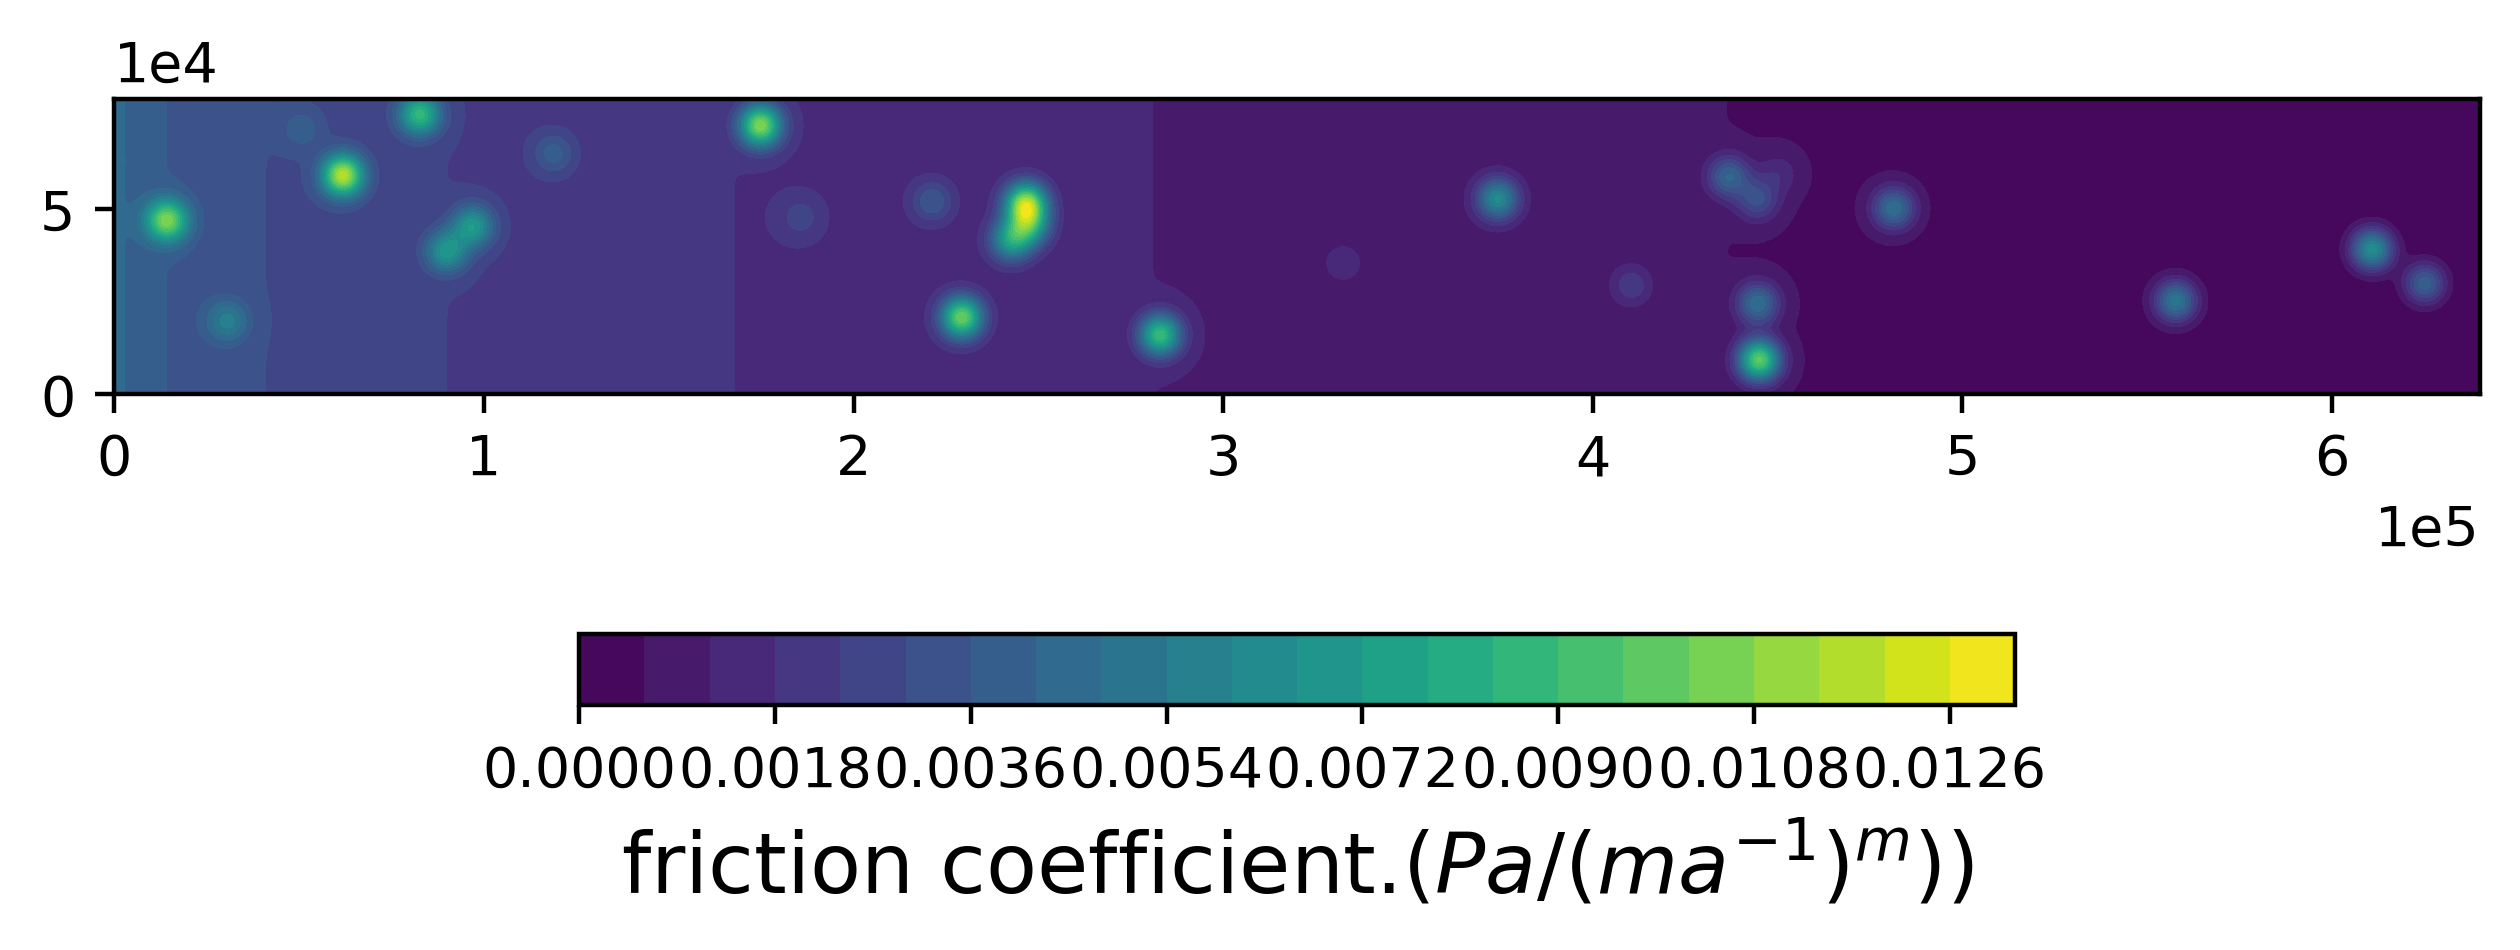

In [10]:
fig, axes = icepack.plot.subplots(dpi=400)
contours = icepack.plot.tricontourf(C, 25, axes=axes)
CS=plt.colorbar(contours, ax=axes, orientation='horizontal', pad=0.15,fraction=.045)
CS.set_label(r'friction coefficient.($Pa/(ma^{-1})^{m})$)',fontsize=15)
plt.tight_layout()
plt.savefig('../figures/fig01/friction.png')

In [11]:
import icepack.models.friction

def friction_coulomb(**kwargs):
    u = kwargs["velocity"]
    h = kwargs["thickness"]
    s = kwargs["surface"]
    C = kwargs["friction"]

    p_W = ρ_W * g * max_value(0, -(s - h))
    p_I = ρ_I * g * h
    N = max_value(0, p_I - p_W)
    τ_c = N / 2

    u_c = (τ_c / C)**m
    u_b = sqrt(inner(u, u))

    return τ_c * (
        (u_c**(1/m + 1) + u_b**(1/m + 1))**(m / (m + 1)) - u_c
    )

def friction_weertman(**kwargs):
    u = kwargs["velocity"]
    h = kwargs["thickness"]
    s = kwargs["surface"]
    C = kwargs["friction"]

    p_W = ρ_W * g * firedrake.max_value(0, h - s)
    p_I = ρ_I * g * h
    ϕ = 1 - p_W / p_I
    return icepack.models.friction.bed_friction(
        velocity=u,
        friction=C * ϕ,
    )

def flotationHeight(zb, Q, rho_I= ρ_I, rho_W=ρ_W):
    """Given bed elevation, determine height of flotation for function space Q.
    Parameters
    ----------
    zb  : firedrake interp function
        bed elevation (m)
    Q : firedrake function space
        function space
    rho_I : [type], optional
        [description], by default rhoI
    rho_W : [type], optional
        [description], by default rhoW
    Returns
    -------
    zF firedrake interp function
        Flotation height (m)
    """
    # computation for height above flotation
    zF = firedrake.interpolate(firedrake.max_value(-zb * (rho_W/rho_I-1), 0), Q)
    return zF

def flotationMask(s, zF, Q, rho_I=ρ_I, rho_W=ρ_W):
    """Using flotation height, create masks for floating and grounded ice.
    Parameters
    ----------
    zF firedrake interp function
        Flotation height (m)
    Q : firedrake function space
        function space
    rho_I : [type], optional
        [description], by default rhoI
    rho_W : [type], optional
        [description], by default rhoW
    Returns
    -------
    floating firedrake interp function
         ice shelf mask 1 floating, 0 grounded
    grounded firedrake interp function
        Grounded mask 1 grounded, 0 floating
    """
    # smooth to avoid isolated points dipping below flotation.
    zAbove = firedrakeSmooth(icepack.interpolate(s - zF, Q), α=100)
    floating = icepack.interpolate(zAbove < 0, Q)
    grounded = icepack.interpolate(zAbove > 0, Q)
    return floating, grounded

In [12]:
smb = Constant(0.5)
a=firedrake.interpolate(smb,Q)
area = firedrake.assemble(Constant(1) * dx(mesh2d))

In [13]:
model = icepack.models.IceStream(friction=friction_weertman)

In [14]:
h_0 = icepack.interpolate(Constant(100), Q)
s_0 = icepack.compute_surface(thickness=h_0, bed=bed)

In [15]:
def normalized_melt(total_melt,floating):
    intMelt = firedrake.assemble(floating * firedrake.dx)
    scale = firedrake.Constant(-1.0 * total_melt/float(intMelt))
    melt = icepack.interpolate(scale * floating, Q)
    return melt


In [16]:
def run_spin_up(solver,C, bed, h, s, u, final_time, dt,total_melt,smb):
    
    zF = flotationHeight(bed, Q)
    num_steps = int(final_time / dt)
    progress_bar = tqdm.trange(num_steps)
    for step in progress_bar:
        
        floating,grounded = flotationMask(s, zF, Q)
        melt = normalized_melt(total_melt,floating)
        a.interpolate(melt+smb)
        h = solver.prognostic_solve(
            dt,
            thickness=h,
            velocity=u,
            accumulation=a,
            thickness_inflow=h_0
        )

        s = icepack.compute_surface(thickness=h, bed=bed)

        u = solver.diagnostic_solve(
            velocity=u,
            thickness=h,
            surface=s,
            fluidity=A,
            friction=C
        )

        min_h = h.dat.data_ro.min()
        avg_h = firedrake.assemble(h * dx) / area
        description = f"avg, min h: {avg_h:4.2f}, {min_h:4.2f}"
        progress_bar.set_description(description)
        
    return h, s, u

In [17]:
def run_melt_variability_obs(solver, C, bed, h, s, u, final_time, dt, total_melt, smb):
    zF = flotationHeight(bed, Q)
    num_steps = int(final_time / dt)
    progress_bar = tqdm.trange(num_steps)
    i=0
    for step in progress_bar:
        floating,grounded = flotationMask(s, zF, Q)
        melt = normalized_melt(total_melt[i],floating)
        a.interpolate(melt+smb)
        h = solver.prognostic_solve(
            dt,
            thickness=h,
            velocity=u,
            accumulation=a,
            thickness_inflow=h_0
        )

        s = icepack.compute_surface(thickness=h, bed=bed)

        u = solver.diagnostic_solve(
            velocity=u,
            thickness=h,
            surface=s,
            fluidity=A,
            friction=C
        )

        min_h = h.dat.data_ro.min()
        avg_h = firedrake.assemble(h * dx) / area
        description = f"avg, min h: {avg_h:4.2f}, {min_h:4.2f}"
        progress_bar.set_description(description)
        i+=1
        
    return h, s, u

In [18]:
def run_melt_variability(solver, C, bed, h, s, u, final_time, dt, melt, smb):
    zF = flotationHeight(bed, Q)
    num_steps = int(final_time / dt)
    progress_bar = tqdm.trange(num_steps)
    for step in progress_bar:
        floating,grounded = flotationMask(s, zF, Q)
        a.interpolate(melt*floating+smb)
        h = solver.prognostic_solve(
            dt,
            thickness=h,
            velocity=u,
            accumulation=a,
            thickness_inflow=h_0
        )

        s = icepack.compute_surface(thickness=h, bed=bed)

        u = solver.diagnostic_solve(
            velocity=u,
            thickness=h,
            surface=s,
            fluidity=A,
            friction=C
        )

        min_h = h.dat.data_ro.min()
        avg_h = firedrake.assemble(h * dx) / area
        description = f"avg, min h: {avg_h:4.2f}, {min_h:4.2f}"
        progress_bar.set_description(description)
        
    return h, s, u

In [19]:
def generate_surface(s,b,sigma):
    X=firedrake.interpolate(mesh2d.coordinates, V).dat.data_ro
    error = np.random.normal(0,sigma, size=s.dat.data.shape)
    s_obs = s.copy(deepcopy=True)
    s_obs.dat.data[:]=error+s.dat.data[:]
    s_obs.dat.data[s_obs.dat.data<b.dat.data]=s.dat.data[s_obs.dat.data<b.dat.data]
    
    return s_obs 
    
def generate_velocity(u,sigma):

    X=firedrake.interpolate(mesh2d.coordinates, V).dat.data_ro
    error = np.random.normal(0,sigma, size=u.dat.data.shape)
    u_obs = u.copy(deepcopy=True)
    u_obs.dat.data[:]=error+u.dat.data[:]
    
    return u_obs

In [20]:
def firedrakeSmooth(q0, α=2e3):
    """[summary]
    Parameters
    ----------
    q0 : firedrake function
        firedrake function to be smooth
    α : float, optional
        parameter that controls the amount of smoothing, which is
        approximately the smoothing lengthscale in m, by default 2e3
    Returns
    -------
    q firedrake interp function
        smoothed result
    """
    q = q0.copy(deepcopy=True)
    J = 0.5 * ((q - q0)**2 + α**2 * firedrake.inner(firedrake.grad(q), firedrake.grad(q))) * firedrake.dx
    F = firedrake.derivative(J, q)
    firedrake.solve(F == 0, q)
    return q

In [21]:
x,y= firedrake.SpatialCoordinate(mesh2d)
u_in, u_out = 20, 2400
velocity_x = u_in + (u_out - u_in) * (x/Lx)**2
u_0 = firedrake.interpolate(firedrake.as_vector((velocity_x, 0)), V)

/tmp/ipykernel_2751706/454160340.py:6: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


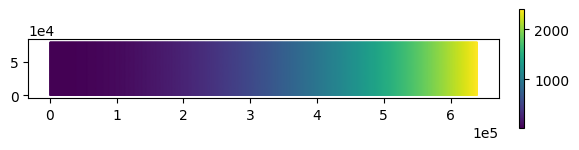

In [22]:
import icepack.plot

fig, axes = icepack.plot.subplots()
colors = firedrake.tripcolor(u_0, axes=axes)
fig.colorbar(colors, ax=axes, fraction=0.012, pad=0.04);
fig.show()

In [23]:
from firedrake import as_vector
opts = {
    'dirichlet_ids': [1],
    'side_wall_ids': [3, 4],
    "diagnostic_solver_type": "petsc",
    "diagnostic_solver_parameters": {
        "snes_type": "newtontr",
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}
solver = icepack.solvers.FlowSolver(model, **opts)

x,y= firedrake.SpatialCoordinate(mesh2d)
u_0 = solver.diagnostic_solve(
    velocity=u_0,
    thickness=h_0,
    surface=s_0,
    fluidity=A,
    friction=C
)


/tmp/ipykernel_2751706/3126509973.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


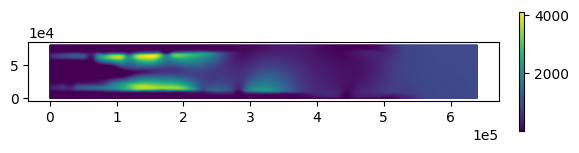

In [24]:
fig, axes = icepack.plot.subplots()
colors = firedrake.tripcolor(u_0, axes=axes)
fig.colorbar(colors, ax=axes, fraction=0.012, pad=0.04);
fig.show()

# Run simulation
We start by defining a user function that can update the thickness surface height and the velocity for several iterations of the prognostic model and return the thickness surface height and velocity of the ice sheet after a chosen length of time.

In [ ]:
import os
final_time = 2000
dt = 1/12

if not os.path.exists('results/mismip-degree1.h5'):
    h, s, u = run_spin_up(
        solver, C, bed, h_0, s_0, u_0, final_time, dt, 0.0, smb
    )
    
    with firedrake.DumbCheckpoint(
        'results/mismip-degree1', mode=firedrake.FILE_CREATE
    ) as checkpoint:
        checkpoint.store(h, name='thickness')
        checkpoint.store(s, name='surface')
        checkpoint.store(u, name='velocity')

else:
    h = firedrake.Function(Q)
    s = firedrake.Function(Q)
    u = firedrake.Function(V)
    
    with firedrake.DumbCheckpoint(
        'results/mismip-degree1', mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(h, name='thickness')
        checkpoint.load(s, name='surface')
        checkpoint.load(u, name='velocity')

avg, min h: 165.05, 34.57:   7%|▍     | 1753/24000 [5:25:27<62:42:09, 10.15s/it]

In [ ]:
import os
final_time = 500
dt = 1/3

if not os.path.exists('results/mismip-degree1-melt.h5'):
    h, s, u = run_spin_up(
        solver, C, bed, h, s, u, final_time, dt, 10e9, smb
    )
    
    with firedrake.DumbCheckpoint(
        'results/mismip-degree1-melt', mode=firedrake.FILE_CREATE
    ) as checkpoint:
        checkpoint.store(h, name='thickness')
        checkpoint.store(s, name='surface')
        checkpoint.store(u, name='velocity')

else:
    h = firedrake.Function(Q)
    s = firedrake.Function(Q)
    u = firedrake.Function(V)
    
    with firedrake.DumbCheckpoint(
        'results/mismip-degree1-melt', mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(h, name='thickness')
        checkpoint.load(s, name='surface')
        checkpoint.load(u, name='velocity')

In [ ]:
fig, axes = icepack.plot.subplots(dpi=400)
contours = icepack.plot.tricontourf(u, 25, axes=axes)
CS=plt.colorbar(contours, ax=axes, orientation='horizontal', pad=0.15,fraction=.045,ticks=[0,250,500,750,1000])
CS.set_label(r'velocity.($ma^{-1}$)',fontsize=15)
plt.tight_layout()
plt.show(fig)
plt.savefig('../figures/fig01/velocity.png')

In [ ]:
fig, axes = icepack.plot.subplots(dpi=400)
contours = icepack.plot.tricontourf(h, 25, axes=axes)
CS=plt.colorbar(contours, ax=axes, orientation='horizontal', pad=0.15,fraction=.045,ticks=[0,250,500,750,1000])
CS.set_label(r'thickness.($m$)',fontsize=15)
plt.tight_layout()
plt.show(fig)
plt.savefig('../figures/fig01/thickness.png')

In [27]:
import os
time = 50
obs_sample_rate = 1/4
num_steps=int(time*obs_sample_rate)
dt=1/24
fraction=.2


if not os.path.exists('../data/forcing/melt_variability_{:.3f}.csv'.format(fraction)):
    N=time/dt
    df = 1/(dt*N);
    f0 = 0.5/dt;
    f1 = np.arange(0,f0+df,df)
    # persistence parameters
    beta = 0.5 # exponent for power law noise (slope of spectrum in log-log space)
    r = 0.95 # lag-1 autocorrelation for AR1 noise
    tau = dt/(1-r) # "memory" of AR1 process
    p0 = 1
    
    
    #power spectra (analytical)
    pb = np.sqrt(p0*(f0/f1[1:])**beta)
    pr = np.sqrt(p0/(1 + r**2 - 2*r*np.cos(2*np.pi*dt*f1[1:])))

    #random phases - must be conjugate symmetric
    phase = np.zeros(int(N),dtype = 'complex_')
    pos_freq = pb[1:int(np.ceil(N/2))]; #does NOT include nyquist or DC

    ranphase=np.random.rand(pos_freq.shape[0]); #note this is uniformly, not gaussian distributed from 0 to 1
    phase_half=1j*2*np.pi*ranphase
    phase[1:len(pos_freq)+1]=phase_half
    phase[int(N)-len(pos_freq):] = np.conj(np.flip(phase_half))
    pb2=np.hstack((pb,np.flip(pb[:int(np.floor(N/2))])))
    pr2=np.hstack((pr,np.flip(pb[:int(np.floor(N/2))])))
    anomaly_std=float(10.0*fraction)
    # combine phase and power spectra:
    pbrand = pb2*np.exp(phase);
    prrand = pr2*np.exp(phase);
    pwhite = np.exp(phase);
    
    white = np.fft.ifft(pwhite);
    white = white - np.mean(white);
    white = np.real(white/np.std(white)*anomaly_std);
    
    pl = np.fft.ifft(pbrand);
    pl = pl-np.mean(pl);
    pl = np.real(pl/np.std(pl)*anomaly_std);
    
    ar1 = np.fft.ifft(prrand);
    ar1 = ar1-np.mean(ar1);
    ar1 = np.real(ar1/np.std(ar1)*anomaly_std);
    d = {'time': np.arange(0,N*dt,dt), 'white': white,'ar1':ar1,'pl':pl }
    melt_data=pd.DataFrame(data=d)
    melt_data.to_csv('../data/forcing/melt_variability_{:.3f}.csv'.format(fraction))
else:
    melt_data=pd.read_csv('../data/forcing/melt_variability_{:.3f}.csv'.format(fraction))

In [28]:
melt_data['ar1'][0:6].values

array([ 1.2822449 , -0.30408141, -1.75688561, -1.29417822, -1.94781632,
        0.31903642])

<IPython.core.display.Javascript object>


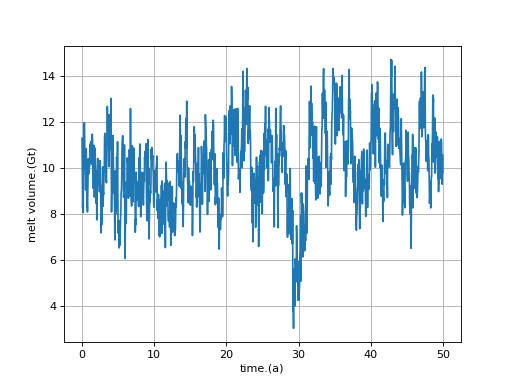

In [37]:
plt.subplots()
plt.xlabel('time.(a)')
plt.ylabel('melt volume.(Gt)')
plt.plot(melt_data['time'],melt_data['ar1']+10)
plt.grid(True)

In [30]:
time = 50
obs_sample_rate = 1/4
num_steps=int(time/obs_sample_rate)

for i in range(num_steps):
    total_melt=(10+melt_data['ar1'][i*int(obs_sample_rate/dt):(1+i)*int(obs_sample_rate/dt)].values)*1e9
    h,s,u=run_melt_variability_obs(
        solver, C, bed, h, s, u, obs_sample_rate, dt, total_melt, smb
    )
    s_obs=generate_surface(s,bed,2.0)
    u_obs=generate_velocity(u,10.0)
    with firedrake.DumbCheckpoint(
        "../data/observations/modified-mismip_{:03d}".format(i), mode=firedrake.FILE_CREATE
                ) as checkpoint:
                checkpoint.store(s_obs, name='surface')
                checkpoint.store(u_obs, name='velocity')
                

avg, min h: 503.70, 13.12: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:12<00:00, 12.13s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.69, 13.09: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:47<00:00,  7.90s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile cla

avg, min h: 503.66, 13.23: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:48<00:00,  8.02s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.66, 13.27: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:46<00:00,  7.69s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.67, 13.29: 100

avg, min h: 503.73, 13.75: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:45<00:00,  7.63s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.73, 13.77: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:46<00:00,  7.73s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.74, 13.81: 100

avg, min h: 503.86, 14.51: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:47<00:00,  7.92s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.87, 14.55: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:47<00:00,  7.98s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.87, 14.58: 100

avg, min h: 503.91, 15.08: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:43<00:00,  7.33s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.92, 15.11: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:48<00:00,  8.11s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.92, 15.15: 100

...

avg, min h: 504.10, 17.13: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:35<00:00,  5.99s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.12, 17.28: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:33<00:00,  5.66s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.14, 17.37: 100

avg, min h: 504.16, 18.13: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:35<00:00,  5.89s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.17, 18.20: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:34<00:00,  5.76s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.17, 18.23: 100

avg, min h: 504.13, 18.83: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.08s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.14, 18.90: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.05s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.14, 18.99: 100

avg, min h: 504.16, 19.80: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.09s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.14, 19.81: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.02s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.14, 19.84: 100

avg, min h: 504.17, 20.70: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:36<00:00,  6.02s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.16, 20.70: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:35<00:00,  5.96s/it]
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 504.15, 20.71: 100

In [31]:
from collections import OrderedDict
ctrls = OrderedDict()
u_obs_timeseries = OrderedDict()
s_obs_timeseries = OrderedDict()
t=float(obs_sample_rate)
i=0
R=firedrake.FunctionSpace(mesh2d, family='R', degree=0)
while t<=time:
    with firedrake.DumbCheckpoint(
        "../data/observations/modified-mismip_{:03d}".format(i), mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(s_obs, name='surface')
        checkpoint.load(u_obs, name='velocity')
    
    s_obs_timeseries[t]=s_obs
    u_obs_timeseries[t]=u_obs
    ctrls[t] = firedrake.Function(R)
    t+=float(obs_sample_rate)  

/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: Deprecation

/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: Deprecation

/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: Deprecation

In [32]:
def solve_melt(ctrls,time=1/4):
    h = firedrake.Function(Q)
    s = firedrake.Function(Q)
    u = firedrake.Function(V)
    
    with firedrake.DumbCheckpoint(
        'results/mismip-degree1-melt', mode=firedrake.FILE_READ
    ) as checkpoint:
        checkpoint.load(h, name='thickness')
        checkpoint.load(s, name='surface')
        checkpoint.load(u, name='velocity')
    
    t=float(obs_sample_rate)
    j = firedrake.Constant(.5)*firedrake.Constant(obs_sample_rate)*firedrake.assemble((u[0]-u_obs_timeseries[t][0])**2*firedrake.dx) + \
    firedrake.Constant(.5)*firedrake.Constant(obs_sample_rate)*firedrake.assemble((u[1]-u_obs_timeseries[t][1])**2*firedrake.dx) + \
    firedrake.Constant(.5)*firedrake.Constant(obs_sample_rate)*firedrake.assemble((s-s_obs_timeseries[t])**2*firedrake.dx) 
    while t<=time:
        h,s,u=run_melt_variability(solver, C, bed, h, s, u, obs_sample_rate, dt, ctrls[t], smb
                                  )
        if t > time - float(obs_sample_rate):
            weight = firedrake.Constant(.5)
        else:
            weight = firedrake.Constant(1.)
        j+=weight*firedrake.Constant(obs_sample_rate)*firedrake.assemble((u-u_obs_timeseries[t])**2*firedrake.dx) + \
        weight*firedrake.Constant(obs_sample_rate)*firedrake.assemble((s-s_obs_timeseries[t])**2*firedrake.dx) 
        t+=float(obs_sample_rate)
    
    return s, u, j


In [33]:
s,u,j = solve_melt(ctrls)

/home/hoffmaao/firedrake/firedrake/src/firedrake/firedrake/checkpointing.py:89: DeprecationWarning: DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will be deprecated after 01/01/2023; use CheckpointFile class instead.",
avg, min h: 503.74, 13.29: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:07<00:00, 11.30s/it]


In [50]:
alpha = firedrake.Constant(1e-1)
regularization = alpha/2*sum([1/firedrake.Constant(obs_sample_rate)*(fb-fa)**2*firedrake.dx for fb, fa in
    zip(list(ctrls.values())[1:], list(ctrls.values())[:-1])])

In [51]:
J = j+firedrake.assemble(regularization)
melt = [Control(c) for c in ctrls.values()]

In [52]:
rf = ReducedFunctional(J,melt)

In [53]:
import pyadjoint, pyadjoint.optimization.rol_solver
class Objective(pyadjoint.optimization.rol_solver.ROLObjective):
    def __init__(self, *args, **kwargs):
        super(Objective, self).__init__(*args, **kwargs)
        
    def update(self, x, flag, iteration):
        try:
            self.val = self.rf(x.dat)
        except firedrake.ConvergenceError:
            self.val = np.inf
            
class Solver(pyadjoint.ROLSolver):
    def __init__(self, problem, parameters, inner_product="L2"):
        super(Solver, self).__init__(problem, parameters, inner_product=inner_product)
        self.rolobjective = Objective(problem.reduced_functional)

In [54]:
problem = pyadjoint.MinimizationProblem(rf)

parameters = {
    "Step": {
        "Type": "Trust Region",
        "Trust Region": {
            "Initial Radius": -1,
            "Subproblem Solver": "Truncated CG",
            "Radius Growing Rate": 2.5,
            "Step Acceptance Threshold": 0.05,
            "Radius Shrinking Threshold": 0.05,
            "Radius Growing Threshold": 0.9,
            "Radius Shrinking Rate (Negative rho)": 0.0625,
            "Radius Shrinking Rate (Positive rho)": 0.25,
            "Radius Growing Rate": 2.5,
            "Sufficient Decrease Parameter": 1e-4,
            "Safeguard Size": 1e2,
        },
    },
    "Status Test": {
        "Gradient Tolerance": 1e-7,
        "Iteration Limit": 100,
    },
    "General": {
        "Print Verbosity": 1,
        "Secant": {
            "Type": "Limited-Memory BFGS",
            "Maximum Storage": 10,
        },
    },
}
time_dependent_solver = Solver(problem, parameters)

In [55]:
opt_ctrls = minimize(rf, options={"maxiter":50})

AttributeError: 'Sum' object has no attribute 'block_variable'